In [11]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch
import torch.nn as nn

In [12]:
class Agent:
    def __init__(self, id):
        self.id = id
        self.belief = random.uniform(-1, 1)
        self.stubbornness = random.uniform(0.1, 0.9)

    def update(self, neighbor_beliefs, external_influence=0.0):
        if not neighbor_beliefs:
            return
        peer_avg = sum(neighbor_beliefs) / len(neighbor_beliefs)
        influence = (peer_avg + external_influence - self.belief) * (1 - self.stubbornness)
        self.belief += influence
        self.belief = max(min(self.belief, 1), -1)

In [13]:
num_agents = 50
steps = 100
G = nx.erdos_renyi_graph(num_agents, 0.1, seed=42)
agents = {i: Agent(i) for i in G.nodes}

avg_beliefs = []
for step in range(steps):  # Fixed: added variable name 'step'
    for i in G.nodes:
        neighbors = list(G.neighbors(i))
        neighbor_beliefs = [agents[n].belief for n in neighbors]  # Fixed: variable name
        agents[i].update(neighbor_beliefs)  # Fixed: variable name
    avg_beliefs.append(np.mean([a.belief for a in agents.values()]))

In [14]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return torch.tensor(X).unsqueeze(-1).float(), torch.tensor(y).unsqueeze(-1).float()

seq_len = 5
X, y = create_sequences(avg_beliefs, seq_len)

In [15]:
class LSTM(nn.Module):
    def __init__(self):  # Fixed: double underscores
        super().__init__()
        self.lstm = nn.LSTM(1, 16, batch_first=True)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm(x)  # Fixed: added underscore for unused variable
        return self.fc(out[:, -1, :])

model = LSTM()
loss_fn = nn.MSELoss()  # Fixed: variable name
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()

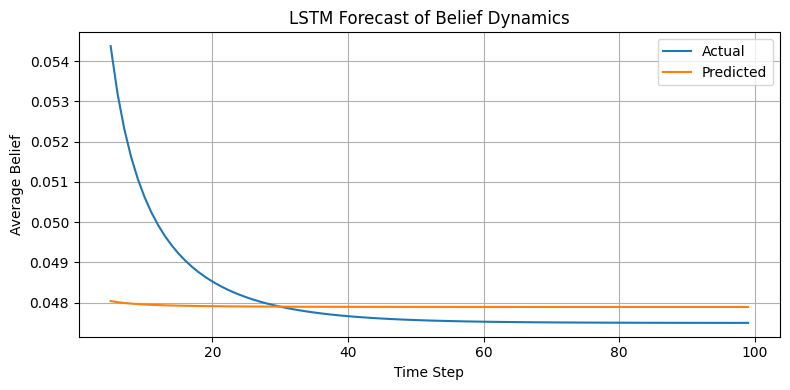

In [16]:
model.eval()
with torch.no_grad():
    forecast = model(X).squeeze().numpy()

# Plot LSTM results
plt.figure(figsize=(8, 4))
plt.plot(range(seq_len, len(avg_beliefs)), y.squeeze(), label="Actual")
plt.plot(range(seq_len, len(avg_beliefs)), forecast, label="Predicted")
plt.title("LSTM Forecast of Belief Dynamics")
plt.xlabel("Time Step")
plt.ylabel("Average Belief")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


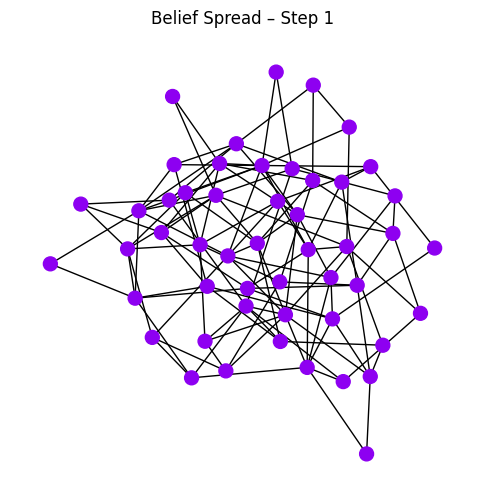

In [17]:
agents = {i: Agent(i) for i in G.nodes}
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    for i in G.nodes:
        neighbors = list(G.neighbors(i))
        neighbor_beliefs = [agents[n].belief for n in neighbors]
        agents[i].update(neighbor_beliefs)

    beliefs = [agents[n].belief for n in G.nodes]
    colors = [(max(min(0.5 + 0.5 * b, 1), 0), 0, max(min(1 - 0.5 * b, 1), 0)) for b in beliefs]
    nx.draw(G, pos, node_color=colors, with_labels=False, node_size=100, ax=ax)
    ax.set_title(f"Belief Spread – Step {frame+1}")

ani = animation.FuncAnimation(fig, update, frames=50, interval=300, repeat=False)

# This is the correct way for Google Colab
from IPython.display import HTML
HTML(ani.to_jshtml())

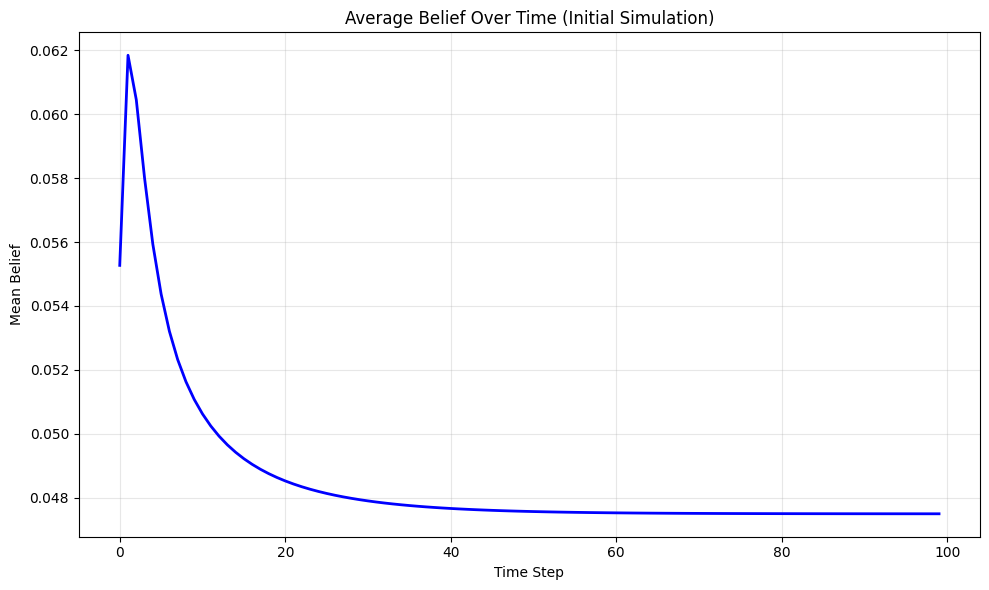

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(avg_beliefs, color='blue', linewidth=2)
plt.title("Average Belief Over Time (Initial Simulation)")
plt.xlabel("Time Step")
plt.ylabel("Mean Belief")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

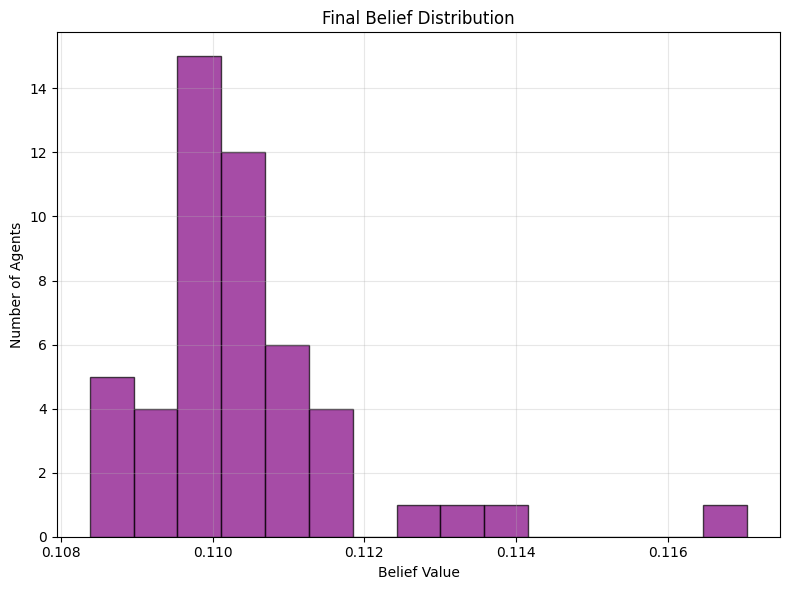

In [19]:
final_beliefs = [agent.belief for agent in agents.values()]
plt.figure(figsize=(8, 6))
plt.hist(final_beliefs, bins=15, color='purple', alpha=0.7, edgecolor='black')
plt.title("Final Belief Distribution")
plt.xlabel("Belief Value")
plt.ylabel("Number of Agents")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
polarization = np.std(final_beliefs)
print(f"Final Polarization (Standard Deviation): {polarization:.4f}")
print(f"Belief Range: [{min(final_beliefs):.3f}, {max(final_beliefs):.3f}]")
print(f"Average Final Belief: {np.mean(final_beliefs):.3f}")

Final Polarization (Standard Deviation): 0.0014
Belief Range: [0.108, 0.117]
Average Final Belief: 0.110
